# Добровольский А.В. ИУ5-23М
## Лабораторная работа №6

**Цель работы:** изучить методы предобработки текстов и решить задачу классификации текста двумя способами:

1. на основе `CountVectorizer` / `TfidfVectorizer`;
2. на основе векторных представлений слов `word2vec`.

В первой части используется библиотека `spaCy` для токенизации, частеречной разметки, лемматизации, выделения именованных сущностей и синтаксического разбора.

Во второй части используется датасет **20 Newsgroups** из `scikit-learn`

## 0. Установка и импорт библиотек

Если библиотеки уже установлены, эту ячейку можно пропустить.

Для первой части нужна модель `en_core_web_sm`. Она содержит компоненты для POS-tagging, lemmatization, NER и dependency parsing.

In [1]:
import sys
import platform

print(sys.executable)
print(platform.python_version())

d:\Study\MMO\Labs\.venv_3.12\Scripts\python.exe
3.12.10


In [3]:
%pip install -q spacy scikit-learn gensim pandas matplotlib
!python -m spacy download en_core_web_sm -q

Note: you may need to restart the kernel to use updated packages.


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [4]:
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from gensim.models import Word2Vec

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.precision', 4)

# Часть 1. Предобработка произвольного текста

Будем использовать одно английское предложение, потому что для английского языка легко подключить готовую модель `spaCy`.

In [5]:
text = "Apple is looking at buying a U.K. startup for $1 billion in San Francisco."
print(text)

Apple is looking at buying a U.K. startup for $1 billion in San Francisco.


## 1.1. Загрузка NLP-модели



In [6]:
import spacy

try:
    nlp = spacy.load('en_core_web_sm')
except OSError as e:
    raise OSError(
        "Модель spaCy 'en_core_web_sm' не установлена. "
        "Выполните команду: !python -m spacy download en_core_web_sm"
    ) from e

doc = nlp(text)
print('Модель загружена:', nlp.meta.get('name', 'en_core_web_sm'))

Модель загружена: core_web_sm


## 1.2. Токенизация

Токенизация — разбиение текста на отдельные элементы: слова, знаки препинания, числа, денежные обозначения и т.д.

In [7]:
tokens = [token.text for token in doc]
print(tokens)

['Apple', 'is', 'looking', 'at', 'buying', 'a', 'U.K.', 'startup', 'for', '$', '1', 'billion', 'in', 'San', 'Francisco', '.']


## 1.3. Частеречная разметка и лемматизация

**Частеречная разметка** определяет грамматическую роль токена: существительное, глагол, прилагательное и т.д.

**Лемматизация** приводит слово к начальной форме: `buying → buy`, `is → be`.

In [8]:
token_info = pd.DataFrame([
    {
        'token': token.text,
        'lemma': token.lemma_,
        'pos': token.pos_,
        'tag': token.tag_,
        'is_stop': token.is_stop,
        'is_alpha': token.is_alpha
    }
    for token in doc
])

token_info

,token,lemma,pos,tag,is_stop,is_alpha
0,Apple,Apple,PROPN,NNP,False,True
1,is,be,AUX,VBZ,True,True
2,looking,look,VERB,VBG,False,True
3,at,at,ADP,IN,True,True
4,buying,buy,VERB,VBG,False,True
5,a,a,DET,DT,True,True
6,U.K.,U.K.,PROPN,NNP,False,False
7,startup,startup,NOUN,NN,False,True
8,for,for,ADP,IN,True,True
9,$,$,SYM,$,False,False


## 1.4. Распознавание именованных сущностей

Именованные сущности — это имена организаций, людей, географические объекты, денежные суммы, даты и другие значимые объекты.

In [9]:
entities = pd.DataFrame([
    {
        'entity': ent.text,
        'label': ent.label_,
        'description': spacy.explain(ent.label_)
    }
    for ent in doc.ents
])

entities

,entity,label,description
0,Apple,ORG,"Companies, agencies, institutions, etc."
1,U.K.,GPE,"Countries, cities, states"
2,$1 billion,MONEY,"Monetary values, including unit"
3,San Francisco,GPE,"Countries, cities, states"


## 1.5. Синтаксический разбор предложения

Разбор показывает связи между словами: какое слово является главным, какую синтаксическую роль играет токен, какие у него зависимые слова.

In [10]:
parse_table = pd.DataFrame([
    {
        'token': token.text,
        'dependency': token.dep_,
        'dependency_description': spacy.explain(token.dep_),
        'head': token.head.text,
        'children': ', '.join(child.text for child in token.children)
    }
    for token in doc
])

parse_table

,token,dependency,dependency_description,head,children
0,Apple,nsubj,nominal subject,looking,
1,is,aux,auxiliary,looking,
2,looking,ROOT,root,looking,"Apple, is, at, startup, ."
3,at,prep,prepositional modifier,looking,buying
4,buying,pcomp,complement of preposition,at,U.K.
5,a,det,determiner,U.K.,
6,U.K.,dobj,direct object,buying,a
7,startup,advcl,adverbial clause modifier,looking,for
8,for,prep,prepositional modifier,startup,billion
9,$,quantmod,modifier of quantifier,billion,


### Краткий вывод по части 1

В первой части текст был преобразован в структуру, пригодную для дальнейшего анализа: получены токены, леммы, части речи, именованные сущности и синтаксические зависимости между словами.

# Часть 2. Классификация текстов

Для классификации используется датасет **20 Newsgroups**. Возьмём несколько категорий, чтобы задача была многоклассовой

In [11]:
categories = [
    'comp.graphics',
    'rec.sport.baseball',
    'sci.space',
    'talk.politics.misc'
]

def make_fallback_dataset():
    """Небольшой резервный датасет на случай отсутствия интернета."""
    topic_templates = {
        'comp.graphics': [
            'computer graphics rendering image pixel shader animation',
            '3d model texture rendering graphics software engine',
            'vector image raster display monitor color graphics',
            'gpu rendering pipeline computer visualization image',
            'graphics card driver OpenGL scene texture'
        ],
        'rec.sport.baseball': [
            'baseball team pitcher game season league score',
            'player hit home run baseball stadium coach',
            'pitcher throws ball batter wins baseball match',
            'league playoff baseball team training season',
            'batting average pitcher catcher baseball game'
        ],
        'sci.space': [
            'space mission orbit rocket planet satellite nasa',
            'astronaut spacecraft launch moon mars telescope',
            'galaxy star orbit space exploration rocket',
            'satellite mission earth orbit science payload',
            'mars rover spacecraft planet space agency'
        ],
        'talk.politics.misc': [
            'government policy election debate law congress',
            'political party campaign vote public policy',
            'senate law government election reform debate',
            'minister parliament political decision public rights',
            'campaign candidate voter policy political speech'
        ]
    }
    rng = np.random.default_rng(42)
    texts, labels = [], []
    for label, topic in enumerate(categories):
        base_texts = topic_templates[topic]
        for i in range(80):
            words = rng.choice('analysis report news update discussion forum important result'.split(), size=5, replace=True)
            text = base_texts[i % len(base_texts)] + ' ' + ' '.join(words)
            texts.append(text)
            labels.append(label)
    return np.array(texts), np.array(labels), categories

try:
    data = fetch_20newsgroups(
        subset='all',
        categories=categories,
        remove=('headers', 'footers', 'quotes'),
        shuffle=True,
        random_state=42
    )
    texts = np.array(data.data)
    labels = np.array(data.target)
    target_names = list(data.target_names)
    dataset_name = '20 Newsgroups'
except Exception as e:
    print('Не удалось загрузить 20 Newsgroups. Используется резервный мини-датасет.')
    print('Причина:', repr(e))
    texts, labels, target_names = make_fallback_dataset()
    dataset_name = 'Fallback synthetic text dataset'

print('Датасет:', dataset_name)
print('Количество документов:', len(texts))
print('Классы:', target_names)
print('Распределение классов:', Counter(labels))

Датасет: 20 Newsgroups
Количество документов: 3729
Классы: ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']
Распределение классов: Counter({np.int64(1): 994, np.int64(2): 987, np.int64(0): 973, np.int64(3): 775})


## 2.1. Первичный просмотр данных

In [12]:
examples_df = pd.DataFrame({
    'text': texts[:5],
    'label': labels[:5],
    'class': [target_names[i] for i in labels[:5]]
})
examples_df

,text,label,class
0,"\nAre you kidding? I'm stuck with the Toronto SkyDome, where their idea\nof a 7th inning stretch is that ""Blue Jays...",1,rec.sport.baseball
1,"\n\n\n\n\n\nSigh. You're absolutely right. We have no political power whatsoever. \nTherefore, we should be oppres...",3,talk.politics.misc
2,"\n\n The above statement ignores reality. The BD WERE provoked.\n\n\n\n\n Damn, Phil. You must have seen a different...",3,talk.politics.misc
3,"\nI'm sorry about your friend. Really. But this anecdote does nothing to\njustify the ""war on drugs"". If anything...",3,talk.politics.misc
4,Hank Greenberg was probably the greatest ever. He was also subject to a\nlot of heckling from bigots on the opposin...,1,rec.sport.baseball


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.25,
    random_state=42,
    stratify=labels
)

print('Размер обучающей выборки:', len(X_train))
print('Размер тестовой выборки:', len(X_test))

Размер обучающей выборки: 2796
Размер тестовой выборки: 933


## Способ 1. Классификация на основе TF-IDF

`TfidfVectorizer` преобразует текст в числовую матрицу. Каждое слово или n-грамма становится признаком, а значение признака отражает важность слова в документе с учётом частоты слова во всём корпусе.

После векторизации используем логистическую регрессию.

In [14]:
tfidf_model = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        max_features=15000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

start = time.perf_counter()
tfidf_model.fit(X_train, y_train)
tfidf_time = time.perf_counter() - start

y_pred_tfidf = tfidf_model.predict(X_test)

tfidf_accuracy = accuracy_score(y_test, y_pred_tfidf)
tfidf_f1 = f1_score(y_test, y_pred_tfidf, average='macro')

print('TF-IDF + LogisticRegression')
print('Accuracy:', round(tfidf_accuracy, 4))
print('Macro F1:', round(tfidf_f1, 4))
print('Время обучения, сек:', round(tfidf_time, 4))

TF-IDF + LogisticRegression
Accuracy: 0.8982
Macro F1: 0.8986
Время обучения, сек: 1.999


In [15]:
print(classification_report(y_test, y_pred_tfidf, target_names=target_names))

                    precision    recall  f1-score   support

     comp.graphics       0.94      0.94      0.94       243
rec.sport.baseball       0.92      0.86      0.89       249
         sci.space       0.81      0.94      0.87       247
talk.politics.misc       0.95      0.85      0.89       194

          accuracy                           0.90       933
         macro avg       0.91      0.90      0.90       933
      weighted avg       0.90      0.90      0.90       933



## Способ 2. Классификация на основе Word2Vec

Здесь каждый токен получает плотный вектор. Документ представляется как среднее значение векторов всех слов документа. После этого над полученными векторами документов обучается логистическая регрессия.

In [16]:
def simple_tokenize(text):
    """Простая токенизация: оставляем только буквенные токены длиной от 2 символов."""
    return re.findall(r'[A-Za-z]{2,}', text.lower())

train_tokens = [simple_tokenize(text) for text in X_train]
test_tokens = [simple_tokenize(text) for text in X_test]

print('Пример токенов:')
print(train_tokens[0][:30])

Пример токенов:
['have', 'routine', 'that', 'changes', 'the', 'color', 'rgb', 'attributes', 'on', 'my', 'vga', 'adapter', 'but', 'it', 'doesn', 'work', 'in', 'the', 'mode', 'that', 'need', 'specifically', 'hex', 'an', 'obscure', 'mode', 'of', 'course', 'but', 'need']


In [17]:
start = time.perf_counter()

w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=1,
    sg=1,          # 1 = Skip-gram, 0 = CBOW
    epochs=30,
    seed=42
)

w2v_train_time = time.perf_counter() - start

print('Размер словаря Word2Vec:', len(w2v.wv))
print('Время обучения Word2Vec, сек:', round(w2v_train_time, 4))

Размер словаря Word2Vec: 15946
Время обучения Word2Vec, сек: 61.7316


In [18]:
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[token] for token in tokens if token in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v = np.vstack([document_vector(tokens, w2v, vector_size=100) for tokens in train_tokens])
X_test_w2v = np.vstack([document_vector(tokens, w2v, vector_size=100) for tokens in test_tokens])

print('Размер матрицы признаков train:', X_train_w2v.shape)
print('Размер матрицы признаков test:', X_test_w2v.shape)

Размер матрицы признаков train: (2796, 100)
Размер матрицы признаков test: (933, 100)


In [19]:
w2v_classifier = LogisticRegression(max_iter=1000, random_state=42)

start = time.perf_counter()
w2v_classifier.fit(X_train_w2v, y_train)
w2v_clf_time = time.perf_counter() - start

y_pred_w2v = w2v_classifier.predict(X_test_w2v)

w2v_accuracy = accuracy_score(y_test, y_pred_w2v)
w2v_f1 = f1_score(y_test, y_pred_w2v, average='macro')

print('Word2Vec average embeddings + LogisticRegression')
print('Accuracy:', round(w2v_accuracy, 4))
print('Macro F1:', round(w2v_f1, 4))
print('Время обучения классификатора, сек:', round(w2v_clf_time, 4))

Word2Vec average embeddings + LogisticRegression
Accuracy: 0.8746
Macro F1: 0.8742
Время обучения классификатора, сек: 0.0776


In [20]:
print(classification_report(y_test, y_pred_w2v, target_names=target_names))

                    precision    recall  f1-score   support

     comp.graphics       0.94      0.90      0.92       243
rec.sport.baseball       0.94      0.86      0.90       249
         sci.space       0.79      0.88      0.84       247
talk.politics.misc       0.84      0.85      0.85       194

          accuracy                           0.87       933
         macro avg       0.88      0.87      0.87       933
      weighted avg       0.88      0.87      0.88       933



## 2.2. Сравнение качества моделей

In [21]:
comparison_df = pd.DataFrame([
    {
        'method': 'TF-IDF + LogisticRegression',
        'accuracy': tfidf_accuracy,
        'macro_f1': tfidf_f1,
        'train_time_sec': tfidf_time
    },
    {
        'method': 'Word2Vec 평균 document vector + LogisticRegression',
        'accuracy': w2v_accuracy,
        'macro_f1': w2v_f1,
        'train_time_sec': w2v_train_time + w2v_clf_time
    }
]).sort_values('macro_f1', ascending=False)

comparison_df

,method,accuracy,macro_f1,train_time_sec
0,TF-IDF + LogisticRegression,0.8982,0.8986,1.9990
1,Word2Vec 평균 document vector + LogisticRegression,0.8746,0.8742,61.8092


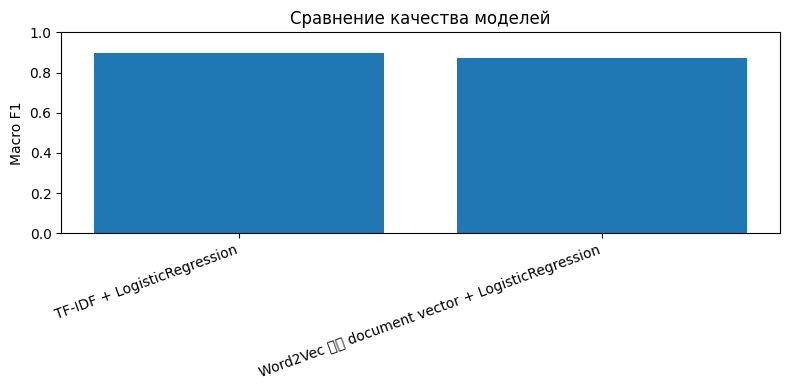

In [22]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df['method'], comparison_df['macro_f1'])
plt.ylabel('Macro F1')
plt.title('Сравнение качества моделей')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

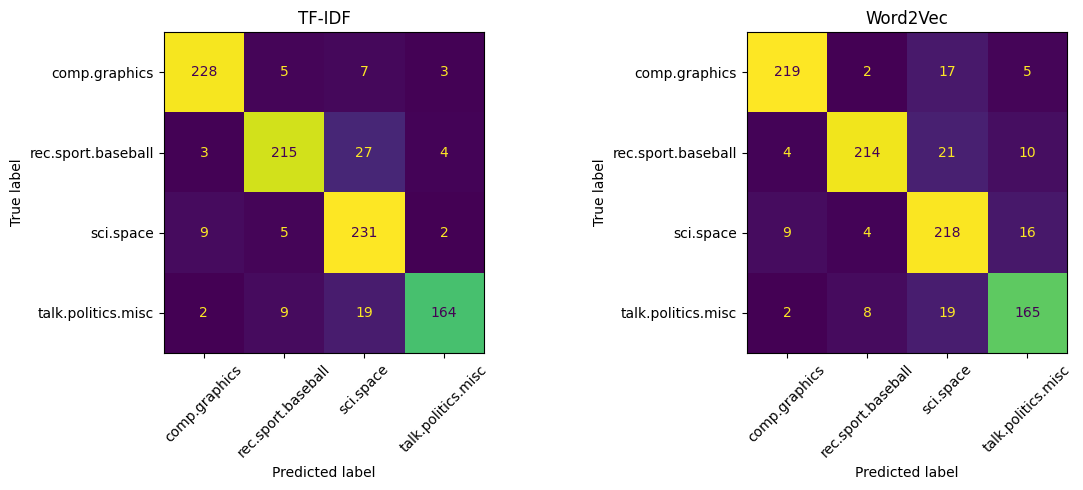

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tfidf),
    display_labels=target_names
).plot(ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title('TF-IDF')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_w2v),
    display_labels=target_names
).plot(ax=axes[1], xticks_rotation=45, colorbar=False)
axes[1].set_title('Word2Vec')

plt.tight_layout()
plt.show()

## Итоговый вывод

В лабораторной работе были выполнены две части:

1. Для произвольного текста выполнены токенизация, частеречная разметка, лемматизация, выделение именованных сущностей и синтаксический разбор.
2. Для задачи классификации текста построены две модели:
   - модель на основе `TfidfVectorizer`;
   - модель на основе усреднённых векторов `Word2Vec`.

Обычно модель на основе TF-IDF показывает более высокое качество на сравнительно небольших текстовых датасетах, потому что она хорошо учитывает частотные признаки конкретного корпуса. Word2Vec может работать лучше при большем объёме данных или при использовании качественных предобученных эмбеддингов.